# Stock Price Movement Predictor

**Leak-free next-day direction classification for the NIFTY 50 index**

Track: Time-Series Machine Learning &nbsp;·&nbsp; Core stack: Python, pandas, scikit-learn, matplotlib

This notebook is the central deliverable of the project. It runs end to end from the committed data snapshot, shows every intermediate result, verifies the absence of temporal leakage programmatically, and writes the artifacts in `results/`, including the JSON file rendered by the web dashboard.

## 1. Executive Summary

NIFTY 50 (`^NSEI`) daily bars from **2015-01-02 to 2026-09-10** (2,879 sessions, 2,792 usable after indicator warm-up). The last 20% of sessions form an untouched chronological test window: **2024-06-05 to 2026-09-09, 558 sessions**.

| Approach | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| **Persistence** (tomorrow matches today) | **54.12%** | 54.45% | 54.45% | 0.544 |
| Majority Class (always UP, from training labels) | 50.36% | 50.36% | 100.00% | 0.670 |
| Raw OHLCV — logistic regression | 50.36% | 50.36% | 100.00% | 0.670 |
| Engineered features — logistic regression | 50.36% | 50.36% | 100.00% | 0.670 |

**The engineered technical indicators did not improve next-day directional classification.** Forward-chaining validation inside the training window selected the strongest regularisation in the grid (C = 0.001) for both models. At that setting both predict UP on every test day, reproducing the Majority baseline exactly (0 discordant days), and their probability rankings are barely better than random (ROC-AUC 0.508 raw, 0.506 engineered). The naive Persistence rule is the most accurate of the four approaches, 3.76 pp above both models, a difference that is not statistically significant over 558 days (exact McNemar p = 0.229).

The evidence-based conclusion is that next-day NIFTY 50 direction is **not meaningfully predictable** from daily OHLCV data and standard technical indicators with a linear classifier. What the project does establish is the methodology: a leak-free target, causal features, a chronological split with an embargo, training-only preprocessing, and 19 of 19 programmatic leakage and validity checks passing, including a truncation test that recomputes every feature on histories cut at date *t* with a maximum difference of 0.0.

## 2. Problem Statement

Given the daily Open, High, Low, Close and Volume of a liquid equity index up to and including trading day *t*, predict whether the index will close higher on the next trading day *t + 1*:

| Label | Meaning |
|---|---|
| **1 = UP** | Close(t+1) > Close(t) |
| **0 = DOWN** | Close(t+1) ≤ Close(t) |

Daily index returns are noisy and close to unpredictable. The useful question is therefore not how high accuracy can be pushed, but whether a model **honestly beats naive rules** when it is evaluated the way it would be used: trained on the past and tested on a later period it has never seen.

## 3. Objective

1. Construct a leak-free next-day target and leak-free temporal features.
2. Establish two naive baselines: **Persistence** (tomorrow matches today) and **Majority Class** (always predict the dominant training class).
3. Train the same classifier twice: on **raw OHLCV** features, then on **raw OHLCV + engineered technical indicators**.
4. Evaluate all four approaches once, on the same untouched chronological test window.
5. Report the class balance, interpret accuracy relative to it, and plot actual against predicted direction.

**Main question:** *do engineered features improve next-day directional classification compared with raw OHLCV features and naive baselines?*

## 4. Dataset and Data Source

| Item | Value |
|---|---|
| Instrument | NIFTY 50 index (National Stock Exchange of India) |
| Ticker | `^NSEI` |
| Source | Yahoo Finance, accessed with `yfinance` (used only to download the data) |
| Frequency | Daily bars |
| Requested window | 2015-01-01 (inclusive) to 2026-09-11 (exclusive) |
| Snapshot | `data/raw/nsei_daily_ohlcv.csv` and `nsei_daily_ohlcv.meta.json` (retrieval time, checksum) |

The window ends at the last *complete* session available when the snapshot was taken: Yahoo's bar for 2026-09-11 did not yet have a closing value, so it was not stored. The notebook always starts from the committed snapshot, which makes every number below reproducible; `python run_pipeline.py --refresh` downloads the same window again. Details are in `data/README.md`.

## 5. Imports and Reproducibility Setup

Reusable logic lives in small modules under `src/` (data loading, target, features, split, baselines, models, evaluation, leakage checks, plots). The notebook calls them step by step so every stage stays visible. Logistic regression with the `lbfgs` solver is deterministic; `random_state` is fixed anyway.

In [1]:
import sys
from pathlib import Path

PROJECT_DIR = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import platform

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import Markdown, display

from src import config, leakage, plots
from src.baselines import majority_class, majority_predictions, persistence_predictions
from src.dashboard import build_payload, write_payload
from src.data_loader import clean_data, load_raw_data
from src.evaluation import (LIMITATIONS, answer_research_questions, class_balance_table, comparison_table,
                            evaluate_predictions, mcnemar_exact, report_frame, rolling_accuracy)
from src.features import (DERIVED_FEATURES, ENGINEERED_FEATURES, FEATURE_DEFINITIONS, RAW_FEATURES,
                          TECHNICAL_INDICATORS, add_technical_features, add_today_direction, build_modeling_frame)
from src.models import fold_date_table, time_series_cv, tune_and_fit
from src.split import chronological_split
from src.target import count_unchanged_closes, create_target

%matplotlib inline
np.random.seed(config.RANDOM_STATE)
plots.apply_style()
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
RESULTS = config.RESULTS_DIR
RESULTS.mkdir(exist_ok=True)


def show_checks(checks):
    """Render leakage-check results as a readable table."""
    table = leakage.to_frame(checks).drop(columns="id")
    display(table.style.hide(axis="index")
            .set_properties(subset=["detail"], **{"text-align": "left", "white-space": "normal"}))


try:
    import yfinance
    yfinance_version = yfinance.__version__
except ImportError:
    yfinance_version = "not installed (snapshot used)"

environment = {
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "scikit-learn": sklearn.__version__,
    "matplotlib": matplotlib.__version__,
    "yfinance": yfinance_version,
}
display(pd.DataFrame.from_dict(environment, orient="index", columns=["version"]))

,version
python,3.12.10
pandas,3.0.5
numpy,2.5.3
scikit-learn,1.9.1
matplotlib,3.11.2
yfinance,1.7.0


## 6. Data Loading

The raw snapshot is loaded exactly as downloaded. Its SHA-256 checksum is compared with the metadata file, so an edited data file raises an error instead of silently producing different results.

In [2]:
raw, metadata = load_raw_data()
print(f"Loaded data/raw/{config.RAW_DATA_FILE.name}: {len(raw):,} rows")
display(pd.DataFrame.from_dict(metadata, orient="index", columns=["value"]))

Loaded data/raw/nsei_daily_ohlcv.csv: 2,879 rows


,value
dataset,NIFTY 50
ticker,^NSEI
source,Yahoo Finance
access_library,yfinance 1.7.0
frequency,Daily
requested_start,2015-01-01
requested_end_exclusive,2026-09-11
retrieved_at_utc,2026-09-11T19:23:44+00:00
rows,2879
first_date,2015-01-02


## 7. Initial Data Inspection

In [3]:
print(f"Shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"Date range: {raw['Date'].min()} to {raw['Date'].max()}")
print(f"Columns: {list(raw.columns)}")
display(raw.head())
display(raw.tail())

missing = pd.DataFrame({"dtype": raw.dtypes.astype(str), "missing values": raw.isna().sum()})
missing["missing %"] = (missing["missing values"] / len(raw)).map("{:.2%}".format)
display(missing)
print(f"Adj Close identical to Close: {np.allclose(raw['Adj Close'], raw['Close'])}")
print(f"Sessions reporting zero volume: {int((raw['Volume'] == 0).sum())}")

Shape: 2,879 rows x 7 columns
Date range: 2015-01-02 to 2026-09-10
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-01-02,8288.700195,8410.599609,8288.700195,8395.450195,8395.450195,101900
1,2015-01-05,8407.950195,8445.599609,8363.900391,8378.400391,8378.400391,118200
2,2015-01-06,8325.299805,8327.849609,8111.350098,8127.350098,8127.350098,172800
3,2015-01-07,8118.649902,8151.200195,8065.450195,8102.100098,8102.100098,164100
4,2015-01-08,8191.399902,8243.500000,8167.299805,8234.599609,8234.599609,143800


,Date,Open,High,Low,Close,Adj Close,Volume
2874,2026-09-04,23910.900391,24005.750000,23895.849609,23897.699219,23897.699219,231400
2875,2026-09-07,23883.150391,23890.000000,23737.900391,23779.150391,23779.150391,205900
2876,2026-09-08,23743.099609,23758.949219,23623.099609,23635.099609,23635.099609,230100
2877,2026-09-09,23522.050781,23571.550781,23431.500000,23431.500000,23431.500000,352900
2878,2026-09-10,23446.599609,23494.949219,23380.099609,23477.800781,23477.800781,253200


,dtype,missing values,missing %
Date,str,0,0.00%
Open,float64,0,0.00%
High,float64,0,0.00%
Low,float64,0,0.00%
Close,float64,0,0.00%
Adj Close,float64,0,0.00%
Volume,int64,0,0.00%


Adj Close identical to Close: True
Sessions reporting zero volume: 28


`Adj Close` equals `Close` for a price index (there are no dividends or splits), so it is not used. The snapshot has no missing values; the one irregularity is a set of sessions that report a volume of zero, handled in the cleaning step.

## 8. Data Cleaning

Cleaning is deliberately conservative and never edits a price:

1. Parse dates, coerce OHLCV to numeric, sort ascending and drop duplicate dates.
2. Remove rows without a complete set of prices (not a complete trading session).
3. Remove rows with impossible values (non-positive prices, negative volume).
4. Check OHLC consistency (High ≥ Open, Close, Low and Low ≤ Open, Close, High) and report violations.
5. Treat a reported volume of **0** as *volume unavailable* (NaN). Zero turnover is not plausible for the NIFTY 50. These sessions keep their valid prices in the series, because deleting them would make the previous day's "next-day" label span two sessions. Rows whose volume features are undefined are excluded later, from **all** approaches alike.

No imputation is performed, so no statistic computed on the full dataset (or on the future) can reach any row.

In [4]:
clean, cleaning_report = clean_data(raw)

steps = {
    "Input already sorted by date": cleaning_report["input_was_sorted"],
    "Unparseable dates removed": cleaning_report["unparseable_dates_removed"],
    "Duplicate dates removed": cleaning_report["duplicate_dates_removed"],
    "Incomplete rows (missing prices) removed": cleaning_report["incomplete_rows_removed"],
    "Impossible rows (price <= 0 or volume < 0) removed": cleaning_report["impossible_rows_removed"],
    "High below Open/Close/Low (reported, not changed)": cleaning_report["high_below_open_or_close"],
    "Low above Open/Close/High (reported, not changed)": cleaning_report["low_above_open_or_close"],
    "Sessions with volume unavailable (reported as 0)": cleaning_report["volume_unavailable_rows"],
}
display(pd.DataFrame.from_dict(steps, orient="index", columns=["result"]))
print("Volume unavailable on:", ", ".join(cleaning_report["volume_unavailable_dates"]))

assert clean.index.is_monotonic_increasing and clean.index.is_unique
assert clean[["Open", "High", "Low", "Close"]].notna().all().all()
print(f"\nClean data: {len(clean):,} sessions from {clean.index.min():%Y-%m-%d} to {clean.index.max():%Y-%m-%d}")
display(clean.describe().T.style.format("{:,.2f}"))

,result
Input already sorted by date,True
Unparseable dates removed,0
Duplicate dates removed,0
Incomplete rows (missing prices) removed,0
Impossible rows (price <= 0 or volume < 0) removed,0
"High below Open/Close/Low (reported, not changed)",0
"Low above Open/Close/High (reported, not changed)",0
Sessions with volume unavailable (reported as 0),28


Volume unavailable on: 2017-04-17, 2018-04-27, 2018-05-21, 2018-07-06, 2018-07-13, 2018-08-10, 2018-09-11, 2018-09-24, 2018-10-10, 2018-10-25, 2018-11-06, 2018-11-15, 2018-11-26, 2018-11-27, 2020-02-17, 2020-09-17, 2021-03-08, 2021-04-07, 2021-05-27, 2021-07-14, 2022-08-16, 2023-03-22, 2023-08-16, 2024-02-19, 2024-04-01, 2024-07-01, 2024-07-02, 2024-07-03

Clean data: 2,879 sessions from 2015-01-02 to 2026-09-10


,count,mean,std,min,25%,50%,75%,max
Open,"2,879.00","15,115.25","6,016.89","7,023.65","10,009.57","12,680.60","19,680.50","26,333.70"
High,"2,879.00","15,183.69","6,039.59","7,034.20","10,056.70","12,741.15","19,769.70","26,373.20"
Low,"2,879.00","15,025.53","5,994.03","6,825.80","9,950.50","12,607.70","19,621.47","26,210.05"
Close,"2,879.00","15,106.09","6,017.42","6,970.60","9,993.40","12,719.95","19,691.92","26,328.55"
Volume,"2,851.00","329,234.48","183,918.59",100.00,"206,450.00","275,100.00","395,600.00","1,811,000.00"


## 9. Target Construction

$$\text{Target}_t = \begin{cases} 1 & \text{if } \text{Close}_{t+1} > \text{Close}_t \quad \text{(UP)} \\ 0 & \text{otherwise} \quad \text{(DOWN or unchanged)} \end{cases}$$

It is implemented in `src/target.py`, the only module that looks forward in time:

```python
next_close = df["Close"].shift(-1)
df["Target"] = np.where(next_close.isna(), np.nan, (next_close > df["Close"]).astype(float))
```

* Using tomorrow's close to build the **label** is correct: it is the quantity being predicted.
* Using tomorrow's close, or any later value, in an **input feature** is forbidden. `Next_Date` and `Next_Close` are kept only for auditing and are never model inputs.
* The final observation has no next close. The common shortcut `(close.shift(-1) > close).astype(int)` would silently label it 0; here it is `NaN`, and the row is excluded from training and testing.

In [5]:
targets = create_target(clean)
display(targets[["Close", "Next_Date", "Next_Close", "Target"]].tail(4))

unchanged_closes = count_unchanged_closes(targets)
print(f"Labelled sessions: {int(targets['Target'].notna().sum()):,} of {len(targets):,}")
print(f"Final session {targets.index[-1]:%Y-%m-%d} has no next close -> Target is NaN and the row is excluded")
print(f"Sessions whose next close is exactly unchanged (labelled DOWN): {unchanged_closes}")

,Close,Next_Date,Next_Close,Target
Date,,,,
2026-09-07,23779.150391,2026-09-08,23635.099609,0.0
2026-09-08,23635.099609,2026-09-09,23431.500000,0.0
2026-09-09,23431.500000,2026-09-10,23477.800781,1.0
2026-09-10,23477.800781,NaT,NaN,NaN


Labelled sessions: 2,878 of 2,879
Final session 2026-09-10 has no next close -> Target is NaN and the row is excluded
Sessions whose next close is exactly unchanged (labelled DOWN): 3


## 10. Feature Engineering

All indicators are implemented directly in pandas (`src/features.py`); no technical-analysis package is used. Each value at date *t* uses only observations at or before *t*: rolling windows are trailing (never centred), exponential averages are computed forward in time (`adjust=False`), and every lag is a positive shift.

* **Feature set A, Raw (5):** Open, High, Low, Close, Volume.
* **Feature set B, Engineered (14):** the raw five, plus **7 technical indicators** (SMA 20, EMA 20, RSI 14, MACD, MACD signal, MACD histogram, 20-day rolling volatility) and **2 derived features** (5-day return, day-over-day volume change).

Both experiments use exactly the same rows. The first sessions are consumed by indicator warm-up (the MACD signal line needs 34 closes) and sessions whose volume features are undefined are dropped. The baselines are evaluated on the same rows, so all four approaches are compared on identical days.

In [6]:
definitions = pd.DataFrame(FEATURE_DEFINITIONS).set_index("name")
display(definitions[["category", "group", "formula", "window"]])
print(f"Raw: {len(RAW_FEATURES)} | technical indicators: {len(TECHNICAL_INDICATORS)} | "
      f"derived: {len(DERIVED_FEATURES)} | engineered set: {len(ENGINEERED_FEATURES)} features")

,category,group,formula,window
name,,,,
Open,Raw,Price,Open_t,1 day
High,Raw,Price,High_t,1 day
Low,Raw,Price,Low_t,1 day
Close,Raw,Price,Close_t,1 day
Volume,Raw,Volume,Volume_t,1 day
SMA_20,Technical indicator,Trend,mean(Close_t-19 ... Close_t),20 days
EMA_20,Technical indicator,Trend,"EMA_t = a*Close_t + (1-a)*EMA_t-1, a = 2/21",20 days
RSI_14,Technical indicator,Momentum,100 - 100 / (1 + avg_gain_14 / avg_loss_14) (...,14 days
MACD,Technical indicator,Momentum,EMA_12(Close) - EMA_26(Close),12 / 26 days


Raw: 5 | technical indicators: 7 | derived: 2 | engineered set: 14 features


In [7]:
labelled = create_target(add_today_direction(add_technical_features(clean)))
assert labelled["Target"].equals(targets["Target"]), "adding features must not change the label"

frame, exclusions = build_modeling_frame(labelled)
feature_sets = {"Raw OHLCV": RAW_FEATURES, "Engineered Features": ENGINEERED_FEATURES}

display(pd.DataFrame.from_dict(exclusions, orient="index", columns=["rows excluded"]))
print(f"Usable labelled rows shared by all four approaches: {len(frame):,} "
      f"({frame.index.min():%Y-%m-%d} to {frame.index.max():%Y-%m-%d})")
display(frame[TECHNICAL_INDICATORS + DERIVED_FEATURES].describe().T.style.format("{:,.4f}"))

,rows excluded
warmup_rows,33
undefined_feature_rows_after_warmup,53
unlabelled_final_rows,1


Usable labelled rows shared by all four approaches: 2,792 (2015-02-20 to 2026-09-09)


,count,mean,std,min,25%,50%,75%,max
SMA_20,"2,792.0000","15,147.7010","6,017.4372","7,170.4000","9,977.7888","13,141.3200","19,660.7969","26,044.9802"
EMA_20,"2,792.0000","15,147.3327","6,014.1221","7,172.6237","9,959.0407","13,126.6508","19,668.9914","26,081.5641"
RSI_14,"2,792.0000",54.1692,12.4351,12.9418,45.3857,54.8451,63.2712,85.5987
MACD,"2,792.0000",37.9874,163.9972,"-1,005.8375",-49.1270,50.5211,129.2746,451.0834
MACD_Signal,"2,792.0000",38.2738,154.3767,-848.3328,-47.2036,50.2824,126.6640,413.9853
MACD_Hist,"2,792.0000",-0.2864,49.7916,-278.2977,-27.1721,-1.5689,25.1722,230.5792
Rolling_Volatility_20,"2,792.0000",0.0089,0.0051,0.0032,0.0061,0.0077,0.0099,0.0560
Return_5D,"2,792.0000",0.0020,0.0226,-0.1902,-0.0099,0.0032,0.0152,0.1052
Volume_Change,"2,792.0000",2.6145,107.7056,-0.9998,-0.1342,-0.0038,0.1544,"5,421.0000"


## 11. Explicit Leakage Verification

The table shows the last sessions of the cleaned data with features and labels side by side. Read each row as: *at the close of `Date`, every value to the left of `Next_Date` is known; the shaded label columns are revealed one session later.*

* Every feature column is known by the close of day *t*.
* `Next_Date`, `Next_Close` and `Target` are determined by day *t + 1*. They are **not** model features.
* The last row has no next session: its `Next_Close` and `Target` are empty, and it is excluded.

A sentence claiming "no leakage" is not evidence, so the next cell runs programmatic checks. The strongest is a **truncation test**: every feature is recomputed on histories cut off at date *t*. If any feature used information from after *t*, its value at *t* would change.

In [8]:
verification_columns = RAW_FEATURES + TECHNICAL_INDICATORS + DERIVED_FEATURES + ["Next_Date", "Next_Close", "Target"]
verification = labelled[verification_columns].tail(6).copy()
verification["Next_Date"] = verification["Next_Date"].dt.strftime("%Y-%m-%d")
label_columns = ["Next_Date", "Next_Close", "Target"]

formats = {c: "{:,.2f}" for c in ["Open", "High", "Low", "Close", "SMA_20", "EMA_20", "RSI_14",
                                  "MACD", "MACD_Signal", "MACD_Hist", "Next_Close"]}
formats.update({"Volume": "{:,.0f}", "Rolling_Volatility_20": "{:.5f}", "Return_5D": "{:+.4f}",
                "Volume_Change": "{:+.4f}", "Target": "{:.0f}"})
display(verification.style.format(formats, na_rep="-")
        .set_properties(subset=label_columns, **{"background-color": "#fff4e5"}))

,Open,High,Low,Close,Volume,SMA_20,EMA_20,RSI_14,MACD,MACD_Signal,MACD_Hist,Rolling_Volatility_20,Return_5D,Volume_Change,Next_Date,Next_Close,Target
Date,,,,,,,,,,,,,,,,,
2026-09-03 00:00:00,"23,997.95","24,025.40","23,873.45","23,873.45","239,100","24,239.03","24,164.88",37.11,-73.45,-21.54,-51.91,0.00339,-0.0090,-0.2502,2026-09-04,"23,897.70",1
2026-09-04 00:00:00,"23,910.90","24,005.75","23,895.85","23,897.70","231,400","24,205.38","24,139.43",38.37,-84.65,-34.16,-50.48,0.00343,-0.0115,-0.0322,2026-09-07,"23,779.15",0
2026-09-07 00:00:00,"23,883.15","23,890.00","23,737.90","23,779.15","205,900","24,165.15","24,105.12",34.72,-101.92,-47.72,-54.20,0.00349,-0.0125,-0.1102,2026-09-08,"23,635.10",0
2026-09-08 00:00:00,"23,743.10","23,758.95","23,623.10","23,635.10","230,100","24,123.32","24,060.36",30.88,-125.77,-63.33,-62.45,0.00357,-0.0175,+0.1175,2026-09-09,"23,431.50",0
2026-09-09 00:00:00,"23,522.05","23,571.55","23,431.50","23,431.50","352,900","24,073.10","24,000.47",26.44,-159.27,-82.52,-76.76,0.00388,-0.0202,+0.5337,2026-09-10,"23,477.80",1
2026-09-10 00:00:00,"23,446.60","23,494.95","23,380.10","23,477.80","253,200","24,027.20","23,950.69",28.94,-180.01,-102.02,-78.00,0.00399,-0.0166,-0.2825,-,-,-


In [9]:
data_checks = leakage.check_chronology(clean) + [
    leakage.check_target(labelled),
    leakage.check_last_row_excluded(clean, frame),
    leakage.check_feature_source(),
]
truncation_check, truncation_detail = leakage.truncation_test(clean, config.TRUNCATION_TEST_POINTS)
data_checks += [truncation_check, leakage.check_feature_lists(feature_sets)]

show_checks(data_checks)
display(truncation_detail.set_index("feature").T.style.format("{:.1e}"))
assert all(check.passed for check in data_checks), "a data, target or feature leakage check failed"

ref,stage,name,status,detail
CHECK 1,Data,Dates sorted chronologically,PASS,2879 sessions from 2015-01-02 to 2026-09-10 are strictly increasing.
CHECK 2,Data,No duplicate dates,PASS,0 duplicated dates after cleaning.
CHECK 3,Target,Target equals next-day movement,PASS,Independent recomputation of 1[Close(t+1) > Close(t)] matches all 2878 labels; the final row's label is undefined (NaN).
CHECK 4,Target,Final unlabeled row excluded,PASS,2026-09-10 has no next close and is absent from the modeling data.
CHECK 5,Features,No look-ahead constructs in feature code,PASS,"Syntax-tree scan of features.py and baselines.py found no negative shift, centred window, backward fill or interpolation; 1 shift(periods) call(s) take a variable lag, which trailing_return() restricts to positive values and the truncation test verifies numerically."
CHECK 5,Features,Features unchanged when the future is removed,PASS,All 14 features recomputed on 40 truncated histories; largest absolute difference = 0.0e+00.
CHECK 6,Features,Target and next-day columns excluded from features,PASS,"Neither feature set contains Target, Next_Close, Next_Date or the Persistence helper columns."


feature,Open,High,Low,Close,Volume,SMA_20,EMA_20,RSI_14,MACD,MACD_Signal,MACD_Hist,Rolling_Volatility_20,Return_5D,Volume_Change
max_abs_difference,0.0e+00,0.0e+00,0.0e+00,0.0e+00,0.0e+00,0.0e+00,0.0e+00,0.0e+00,0.0e+00,0.0e+00,0.0e+00,0.0e+00,0.0e+00,0.0e+00


## 12. Chronological Train/Test Split

The final 20% of usable sessions form an untouched test window; the earlier 80% are used for training and model selection. Nothing is shuffled.

One subtlety: the label of the last row before the test window is computed from the close of the first test day. That single row (a one-session **embargo**) is purged, so every training label is fully resolved before the test window begins. The invariants `max(train date) < min(test date)` and `max(date of any Close(t+1) used in a training label) < min(test date)` are asserted below.

,Start,End,Rows
Partition,,,
Train,2015-02-20,2024-06-03,2233
Embargo,2024-06-04,2024-06-04,1
Test,2024-06-05,2026-09-09,558


Training: 2015-02-20 -> 2024-06-03 (2,233 sessions)
Embargo:  2024-06-04 (1 session purged)
Testing:  2024-06-05 -> 2026-09-09 (558 sessions)


,Partition,Close,Next_Date,Next_Close,Target
Date,,,,,
2024-05-31,Train,22530.699219,2024-06-03,23263.900391,1
2024-06-03,Train,23263.900391,2024-06-04,21884.500000,0
2024-06-04,Embargo (purged),21884.500000,2024-06-05,22620.349609,1
2024-06-05,Test,22620.349609,2024-06-06,22821.400391,1
2024-06-06,Test,22821.400391,2024-06-07,23290.150391,1


ref,stage,name,status,detail
CHECK 7,Split,Train period ends before test period,PASS,max(train date) = 2024-06-03 < min(test date) = 2024-06-05.
CHECK 7,Split,Every training label resolved before the test window,PASS,Latest Close(t+1) used by a training label is from 2024-06-04; 1 embargo row(s) purged.
CHECK 8,Split,"Chronological split, no shuffling",PASS,Train + embargo + test reproduce the original date order exactly; no random split is used.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


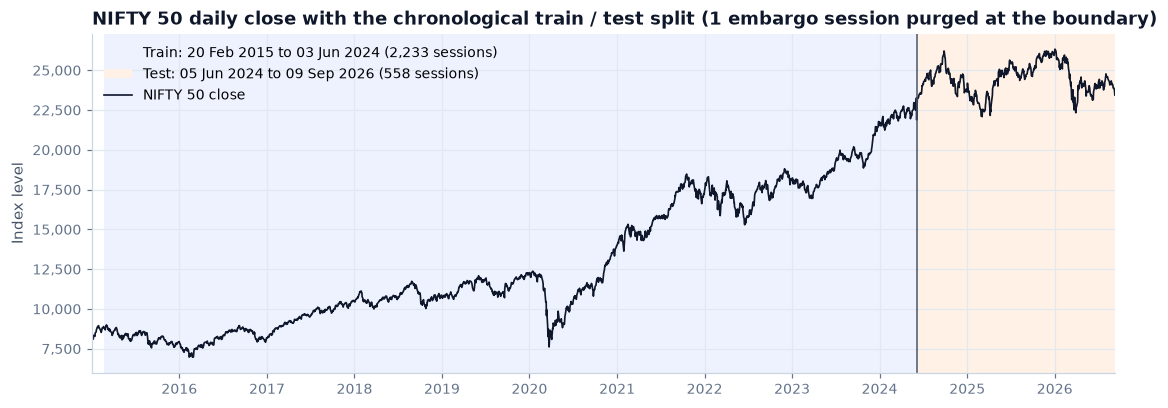

In [10]:
split = chronological_split(frame, config.TEST_FRACTION, config.EMBARGO_ROWS)
display(split.summary())
print(f"Training: {split.train.index.min():%Y-%m-%d} -> {split.train.index.max():%Y-%m-%d} ({len(split.train):,} sessions)")
print(f"Embargo:  {split.embargo.index.min():%Y-%m-%d} ({len(split.embargo)} session purged)")
print(f"Testing:  {split.test.index.min():%Y-%m-%d} -> {split.test.index.max():%Y-%m-%d} ({len(split.test):,} sessions)")
assert split.train.index.max() < split.test.index.min()

boundary = pd.concat([
    split.train.tail(2).assign(Partition="Train"),
    split.embargo.assign(Partition="Embargo (purged)"),
    split.test.head(2).assign(Partition="Test"),
])[["Partition", "Close", "Next_Date", "Next_Close", "Target"]]
display(boundary)

split_checks = leakage.check_split(split, frame)
show_checks(split_checks)

y_train, y_test = split.train["Target"], split.test["Target"]
fig = plots.plot_train_test_split(clean["Close"], split.train, split.embargo, split.test)
plots.save_figure(fig, RESULTS / "train_test_split.png")
plt.show()

## 13. Class Balance Analysis

Accuracy only means something relative to the class balance: if 55% of days are UP, a rule that always answers UP is already 55% accurate without learning anything. The shares below are computed for the usable data, the training window and the test window.

,UP count,DOWN count,Total,UP %,DOWN %,Assessment
Split,,,,,,
Overall (usable),1486,1306,2792,53.22%,46.78%,mildly imbalanced
Train,1204,1029,2233,53.92%,46.08%,mildly imbalanced
Test,281,277,558,50.36%,49.64%,balanced


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


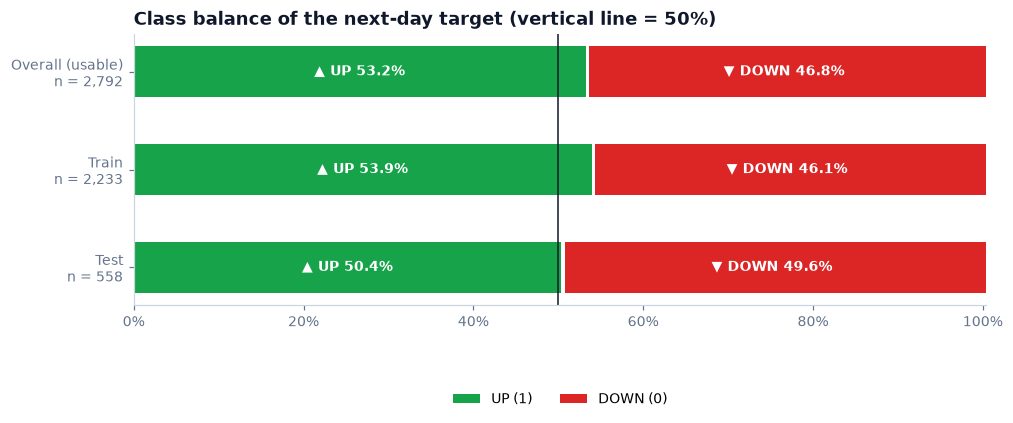

In [11]:
balance = class_balance_table(frame["Target"], y_train, y_test)
balance.to_csv(RESULTS / "class_balance.csv", float_format="%.6f")
display(balance.style.format({"UP %": "{:.2%}", "DOWN %": "{:.2%}"}))

fig = plots.plot_class_balance(balance)
plots.save_figure(fig, RESULTS / "class_balance.png")
plt.show()

In [12]:
overall, train_row, test_row = (balance.loc[k] for k in ["Overall (usable)", "Train", "Test"])
display(Markdown(
    f"**Reading the class balance.** UP days make up {overall['UP %']:.2%} of the usable data, "
    f"{train_row['UP %']:.2%} of the training window and {test_row['UP %']:.2%} of the test window, so the "
    f"target is **{overall['Assessment']}**. A rule that always predicts UP would be right on "
    f"{test_row['UP %']:.2%} of test days, and that figure (not 50%) is the floor a model has to clear. "
    f"The assignment's \"~53%\" example is not assumed; these are the observed shares.\n\n"
    f"Thresholds used (share of the majority class): at most {config.BALANCED_MAX_SHARE:.0%} is *balanced*, "
    f"at most {config.MILD_IMBALANCE_MAX_SHARE:.0%} is *mildly imbalanced*, anything above is *meaningfully imbalanced*."
))

**Reading the class balance.** UP days make up 53.22% of the usable data, 53.92% of the training window and 50.36% of the test window, so the target is **mildly imbalanced**. A rule that always predicts UP would be right on 50.36% of test days, and that figure (not 50%) is the floor a model has to clear. The assignment's "~53%" example is not assumed; these are the observed shares.

Thresholds used (share of the majority class): at most 52% is *balanced*, at most 60% is *mildly imbalanced*, anything above is *meaningfully imbalanced*.

## 14. Persistence Baseline

"Tomorrow matches today":

$$\hat{y}_t = \mathbb{1}\left[\text{Close}_t > \text{Close}_{t-1}\right]$$

Today's direction is known at the close of day *t*, so the rule uses no future information. Its prediction for the next session is compared with the same `Target` as every other approach, on the same test days.

In [13]:
persistence_test = persistence_predictions(split.test)
example = (split.test[["Close", "Prev_Close", "Today_Direction", "Next_Close", "Target"]]
           .head(6).assign(Persistence=persistence_test.head(6)))
display(example.style.format({"Close": "{:,.2f}", "Prev_Close": "{:,.2f}", "Next_Close": "{:,.2f}"}))
print(f"Persistence predicts UP on {persistence_test.mean():.1%} of test days")

,Close,Prev_Close,Today_Direction,Next_Close,Target,Persistence
Date,,,,,,
2024-06-05 00:00:00,"22,620.35","21,884.50",1,"22,821.40",1,1
2024-06-06 00:00:00,"22,821.40","22,620.35",1,"23,290.15",1,1
2024-06-07 00:00:00,"23,290.15","22,821.40",1,"23,259.20",0,1
2024-06-10 00:00:00,"23,259.20","23,290.15",0,"23,264.85",1,0
2024-06-11 00:00:00,"23,264.85","23,259.20",1,"23,322.95",1,1
2024-06-12 00:00:00,"23,322.95","23,264.85",1,"23,398.90",1,1


Persistence predicts UP on 50.4% of test days


## 15. Majority Class Baseline

The dominant class is determined from the **training labels only** and predicted for every test day. The test labels are never consulted; the check below reports the test-set majority only to show that it was not used.

In [14]:
majority, majority_summary = majority_class(y_train)
majority_test = majority_predictions(split.test.index, majority)
display(pd.DataFrame(
    {"count": [majority_summary["up"], majority_summary["down"], majority_summary["total"]],
     "share": [f"{majority_summary['up_pct']:.2%}", f"{majority_summary['down_pct']:.2%}", "100.00%"]},
    index=["UP (1)", "DOWN (0)", "Total training labels"],
))
majority_label = "UP (1)" if majority == 1 else "DOWN (0)"
print(f"Dominant training class: {majority_label} -> the baseline predicts {majority_label} "
      f"for all {len(majority_test):,} test days")

baseline_checks = [leakage.check_majority(majority, y_train, y_test),
                   leakage.check_persistence(clean, split.test, persistence_test)]
show_checks(baseline_checks)

,count,share
UP (1),1204,53.92%
DOWN (0),1029,46.08%
Total training labels,2233,100.00%


Dominant training class: UP (1) -> the baseline predicts UP (1) for all 558 test days


ref,stage,name,status,detail
CHECK 11,Baselines,Majority class taken from training labels,PASS,"Training UP share 53.92% -> predict UP. (The test-set majority, UP, was not used.)"
CHECK 12,Baselines,Persistence uses only information up to day t,PASS,Persistence(t) = 1[Close(t) > Close(t-1)] recomputed independently for every test day; it matches the realised next-day label on 54.1% of days (a rule that could see tomorrow would match 100%).


## 16. Time-Series Validation and Hyperparameter Selection

Both models are the same `Pipeline(StandardScaler → LogisticRegression)`. Only the inverse regularisation strength **C** is tuned, over a small grid fixed before any evaluation: 0.001, 0.01, 0.1, 1, 10, 100.

* Selection uses `TimeSeriesSplit` (5 forward-chaining folds, with a gap of one session) **inside the training window only**.
* The scaler is part of the pipeline, so it is re-fitted on each fold's fitting block and never sees validation or test rows.
* The selection metric is accuracy, the project's central metric. Ties resolve to the smallest C.
* After selection the pipeline is re-fitted once on the full training window, and it is evaluated **once** on the test window.

In [15]:
cv = time_series_cv()
folds = fold_date_table(split.train.index, cv)
display(folds)

cv_check = leakage.check_cv_folds(cv, len(split.train))
show_checks([cv_check])
cv_description = (f"TimeSeriesSplit(n_splits={cv.n_splits}, gap={cv.gap}) inside the training window; "
                  f"C grid {config.C_GRID}; selection metric: {config.TUNING_METRIC}")

,fit_start,fit_end,validation_start,validation_end,fit_rows,validation_rows
fold,,,,,,
1,2015-02-20,2016-08-29,2016-08-31,2018-03-07,372,372
2,2015-02-20,2018-03-06,2018-03-08,2019-10-24,744,372
3,2015-02-20,2019-10-23,2019-10-25,2021-05-07,1116,372
4,2015-02-20,2021-05-06,2021-05-10,2022-11-15,1488,372
5,2015-02-20,2022-11-14,2022-11-16,2024-06-03,1860,372


ref,stage,name,status,detail
CHECK 10,Validation,Hyper-parameter search never sees the test set,PASS,"All 5 TimeSeriesSplit folds (gap = 1) index only the 2233 training rows, and each validation block starts after its fitting block ends."


## 17. Raw OHLCV Model

Feature set A: Open, High, Low, Close and Volume.

In [16]:
def show_cv(model):
    table = model.cv_results.set_index("C")
    display(table.style.format("{:.4f}", subset=[c for c in table.columns if c != "rank"]))


raw_model = tune_and_fit("Raw OHLCV", split.train[RAW_FEATURES], y_train, cv=cv)
print(f"Raw OHLCV model: selected C = {raw_model.best_C:g}")
show_cv(raw_model)

Raw OHLCV model: selected C = 0.001


,mean_validation_accuracy,std_validation_accuracy,mean_train_accuracy,rank,fold_1,fold_2,fold_3,fold_4,fold_5
C,,,,,,,,,
0.001000,0.5349,0.0406,0.5280,1,0.4758,0.5215,0.5833,0.5161,0.5780
0.010000,0.5167,0.0307,0.5268,2,0.4758,0.5188,0.5027,0.5161,0.5699
0.100000,0.5140,0.0287,0.5286,4,0.4704,0.5215,0.5027,0.5161,0.5591
1.000000,0.5167,0.0326,0.5281,2,0.4677,0.5215,0.5081,0.5161,0.5699
10.000000,0.5129,0.0245,0.5284,5,0.4704,0.5108,0.5296,0.5108,0.5430
100.000000,0.5113,0.0215,0.5298,6,0.4731,0.5296,0.5215,0.5027,0.5296


## 18. Engineered Feature Model

Feature set B: raw OHLCV plus the seven technical indicators and the two derived features, with the identical pipeline, grid and folds.

Engineered model: selected C = 0.001


,mean_validation_accuracy,std_validation_accuracy,mean_train_accuracy,rank,fold_1,fold_2,fold_3,fold_4,fold_5
C,,,,,,,,,
0.001000,0.5323,0.0363,0.5299,1,0.4785,0.5215,0.5672,0.5161,0.5780
0.010000,0.5054,0.0308,0.5350,2,0.4892,0.4785,0.4892,0.5054,0.5645
0.100000,0.4849,0.0263,0.5361,6,0.4919,0.4785,0.4758,0.4489,0.5296
1.000000,0.4898,0.0258,0.5373,4,0.4946,0.4758,0.4973,0.4516,0.5296
10.000000,0.4887,0.0229,0.5381,5,0.4946,0.4812,0.5161,0.4489,0.5027
100.000000,0.4968,0.0313,0.5409,3,0.4866,0.5242,0.5403,0.4543,0.4785


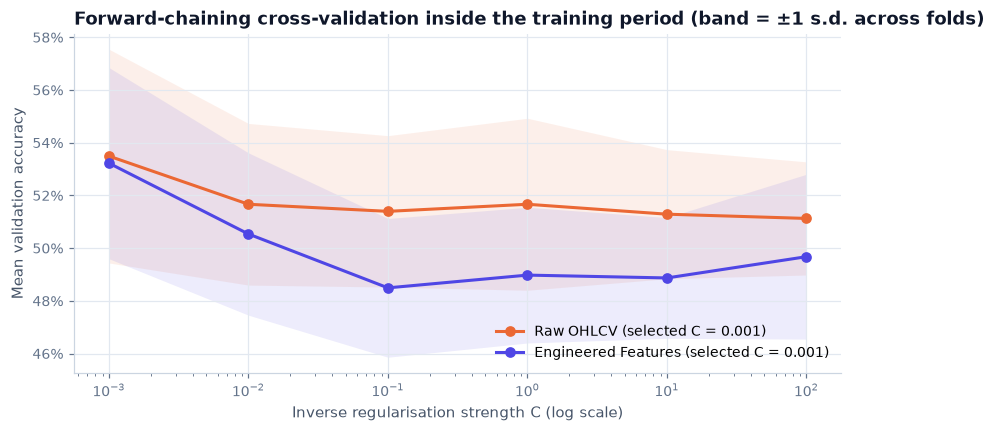

ref,stage,name,status,detail
CHECK 9,Preprocessing,Scaler fitted on training rows only (Raw OHLCV),PASS,"StandardScaler saw 2233 rows (= training rows) and its Close mean 12,876.7 equals the training mean, not the train+test mean 15,197.5."
CHECK 9,Preprocessing,Scaler fitted on training rows only (Engineered Features),PASS,"StandardScaler saw 2233 rows (= training rows) and its Close mean 12,876.7 equals the training mean, not the train+test mean 15,197.5."


In [17]:
eng_model = tune_and_fit("Engineered Features", split.train[ENGINEERED_FEATURES], y_train, cv=cv)
tuned = {"Raw OHLCV": raw_model, "Engineered Features": eng_model}
print(f"Engineered model: selected C = {eng_model.best_C:g}")
show_cv(eng_model)

cv_results = pd.concat({name: m.cv_results.set_index("C") for name, m in tuned.items()}, names=["model", "C"])
cv_results.to_csv(RESULTS / "cv_results.csv", float_format="%.6f")

fig = plots.plot_cv_curves({n: m.cv_results for n, m in tuned.items()}, {n: m.best_C for n, m in tuned.items()})
plots.save_figure(fig, RESULTS / "cv_accuracy_by_C.png")
plt.show()

model_checks = [leakage.check_scaler(m.pipeline, split.train[m.features], frame[m.features], name)
                for name, m in tuned.items()]
show_checks(model_checks)

In [18]:
def cv_note(model):
    table = model.cv_results.sort_values("C")
    best = table.loc[table["C"] == model.best_C].iloc[0]
    loosest = table.iloc[-1]
    at_edge = model.best_C == min(config.C_GRID)
    note = (f"* **{model.name}:** C = {model.best_C:g}"
            + (" (the smallest value in the grid, i.e. the strongest regularisation)" if at_edge else "")
            + f"; mean validation accuracy {best['mean_validation_accuracy']:.2%} "
              f"(± {best['std_validation_accuracy']:.2%} across folds), against "
              f"{loosest['mean_validation_accuracy']:.2%} at C = {loosest['C']:g}.")
    return note, at_edge


notes = [cv_note(m) for m in tuned.values()]
text = "**What the validation shows.**\n\n" + "\n".join(n for n, _ in notes)
if all(edge for _, edge in notes):
    text += ("\n\nBoth searches prefer the strongest shrinkage available. Strong regularisation pulls the "
             "coefficients toward zero and the predicted probabilities toward the training base rate; when "
             "forward validation prefers it, the features carry little signal that transfers from one period "
             "to the next. The grid was fixed in advance and is not widened after the fact.")
display(Markdown(text))

**What the validation shows.**

* **Raw OHLCV:** C = 0.001 (the smallest value in the grid, i.e. the strongest regularisation); mean validation accuracy 53.49% (± 4.06% across folds), against 51.13% at C = 100.
* **Engineered Features:** C = 0.001 (the smallest value in the grid, i.e. the strongest regularisation); mean validation accuracy 53.23% (± 3.63% across folds), against 49.68% at C = 100.

Both searches prefer the strongest shrinkage available. Strong regularisation pulls the coefficients toward zero and the predicted probabilities toward the training base rate; when forward validation prefers it, the features carry little signal that transfers from one period to the next. The grid was fixed in advance and is not widened after the fact.

## 19. Final Test Evaluation

This is the only place where the test window is used. Every approach produces a prediction for the same test sessions; the models use a 0.5 threshold on their predicted probability of UP. Positive class for precision, recall and F1: **UP = 1**.

Besides the point metrics, every accuracy gets a 95% Wilson interval, and an exact McNemar test compares paired predictions on the same days: a direct test of whether two approaches differ by more than chance.

In [19]:
X_test = {name: split.test[m.features] for name, m in tuned.items()}
prob_up = {name: pd.Series(m.pipeline.predict_proba(X_test[name])[:, 1], index=split.test.index)
           for name, m in tuned.items()}
pred = {name: pd.Series(m.pipeline.predict(X_test[name]), index=split.test.index, dtype=int)
        for name, m in tuned.items()}

predictions_by_approach = {
    "Persistence": persistence_test,
    "Majority Class": majority_test,
    "Raw OHLCV": pred["Raw OHLCV"],
    "Engineered Features": pred["Engineered Features"],
}
metrics = {name: evaluate_predictions(y_test, p, prob_up.get(name)) for name, p in predictions_by_approach.items()}
same_window_check = leakage.check_same_window(predictions_by_approach, split.test.index)

significance = {
    "Engineered Features vs Raw OHLCV": mcnemar_exact(y_test, pred["Engineered Features"], pred["Raw OHLCV"]),
    "Engineered Features vs Majority Class": mcnemar_exact(y_test, pred["Engineered Features"], majority_test),
    "Engineered Features vs Persistence": mcnemar_exact(y_test, pred["Engineered Features"], persistence_test),
    "Raw OHLCV vs Majority Class": mcnemar_exact(y_test, pred["Raw OHLCV"], majority_test),
    "Raw OHLCV vs Persistence": mcnemar_exact(y_test, pred["Raw OHLCV"], persistence_test),
}

test_predictions = pd.DataFrame({
    "Actual": y_test,
    "Persistence": persistence_test,
    "Majority": majority_test,
    "Raw_Pred": pred["Raw OHLCV"],
    "Raw_Prob_Up": prob_up["Raw OHLCV"],
    "Engineered_Pred": pred["Engineered Features"],
    "Engineered_Prob_Up": prob_up["Engineered Features"],
})
test_predictions.index.name = "Date"
test_predictions.to_csv(RESULTS / "test_predictions.csv", float_format="%.6f")

significance_table = pd.DataFrame(significance).T
significance_table.columns = ["A right, B wrong", "A wrong, B right", "Discordant days", "Exact McNemar p"]
display(significance_table.style.format({"Exact McNemar p": "{:.3f}"}))

,"A right, B wrong","A wrong, B right",Discordant days,Exact McNemar p
Engineered Features vs Raw OHLCV,0.000000,0.000000,0.000000,1.000
Engineered Features vs Majority Class,0.000000,0.000000,0.000000,1.000
Engineered Features vs Persistence,128.000000,149.000000,277.000000,0.229
Raw OHLCV vs Majority Class,0.000000,0.000000,0.000000,1.000
Raw OHLCV vs Persistence,128.000000,149.000000,277.000000,0.229


## 20. Four-Way Comparison Table

The required comparison, exported to `results/four_way_comparison.csv`.

**Required four-way comparison** (test window, positive class = UP)

,Accuracy,Precision,Recall,F1
Approach,,,,
Persistence,54.12%,54.45%,54.45%,54.45%
Majority Class,50.36%,50.36%,100.00%,66.98%
Raw OHLCV,50.36%,50.36%,100.00%,66.98%
Engineered Features,50.36%,50.36%,100.00%,66.98%


**Extended metrics**

,Accuracy,Precision,Recall,F1,Balanced Accuracy,ROC-AUC,Predicted UP rate,Test days
Approach,,,,,,,,
Persistence,54.12%,54.45%,54.45%,54.45%,54.12%,n/a,50.4%,558
Majority Class,50.36%,50.36%,100.00%,66.98%,50.00%,n/a,100.0%,558
Raw OHLCV,50.36%,50.36%,100.00%,66.98%,50.00%,0.508,100.0%,558
Engineered Features,50.36%,50.36%,100.00%,66.98%,50.00%,0.506,100.0%,558


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


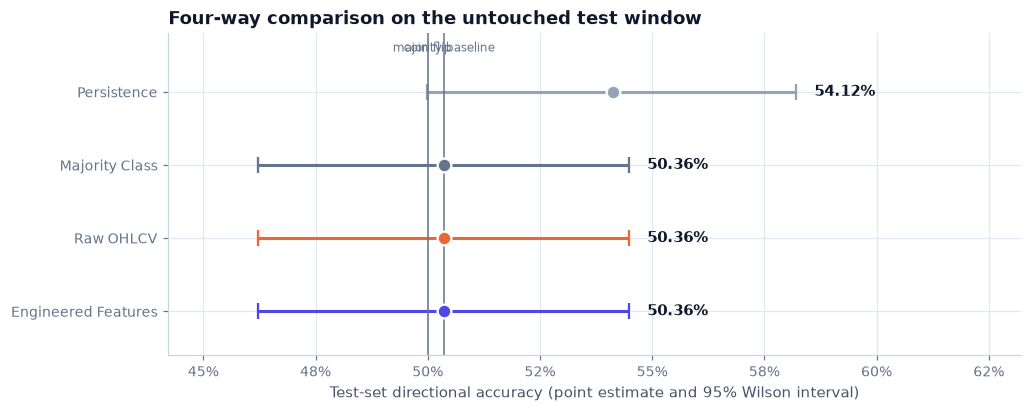

In [20]:
comparison = comparison_table(metrics)
comparison.to_csv(RESULTS / "four_way_comparison.csv", float_format="%.6f")

display(Markdown("**Required four-way comparison** (test window, positive class = UP)"))
display(comparison[["Accuracy", "Precision", "Recall", "F1"]].style.format("{:.2%}")
        .highlight_max(props="font-weight: 700; background-color: #eef2ff"))

display(Markdown("**Extended metrics**"))
display(comparison.style.format({
    "Accuracy": "{:.2%}", "Precision": "{:.2%}", "Recall": "{:.2%}", "F1": "{:.2%}",
    "Balanced Accuracy": "{:.2%}", "ROC-AUC": "{:.3f}", "Predicted UP rate": "{:.1%}", "Test days": "{:,}",
}, na_rep="n/a"))

fig = plots.plot_four_way_comparison(metrics, metrics["Majority Class"]["accuracy"])
plots.save_figure(fig, RESULTS / "four_way_comparison.png")
plt.show()

## 21. Classification Reports

In [21]:
reports = {name: report_frame(y_test, pred[name]) for name in tuned}
for name, report in reports.items():
    display(Markdown(f"**{name}** (C = {tuned[name].best_C:g})"))
    display(report.style.format({"precision": "{:.3f}", "recall": "{:.3f}", "f1-score": "{:.3f}",
                                 "support": "{:,}"}, na_rep=""))
pd.concat(reports, names=["model", "class"]).to_csv(RESULTS / "classification_reports.csv", float_format="%.6f")

**Raw OHLCV** (C = 0.001)

,precision,recall,f1-score,support
DOWN (0),0.000,0.000,0.000,277
UP (1),0.504,1.000,0.670,281
accuracy,,,0.504,558
macro avg,0.252,0.500,0.335,558
weighted avg,0.254,0.504,0.337,558


**Engineered Features** (C = 0.001)

,precision,recall,f1-score,support
DOWN (0),0.000,0.000,0.000,277
UP (1),0.504,1.000,0.670,281
accuracy,,,0.504,558
macro avg,0.252,0.500,0.335,558
weighted avg,0.254,0.504,0.337,558


## 22. Confusion Matrices

Rows are the actual class and columns the predicted class; the percentages are shares of each actual class.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


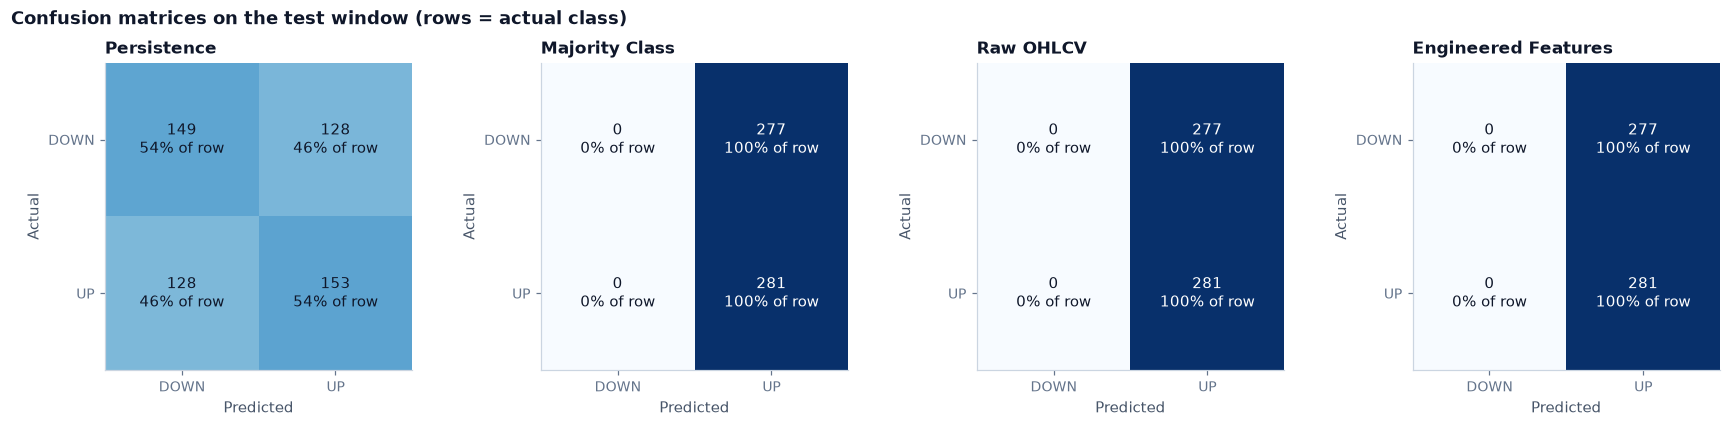

,True DOWN (TN),False UP (FP),False DOWN (FN),True UP (TP)
Approach,,,,
Persistence,149,128,128,153
Majority Class,0,277,0,281
Raw OHLCV,0,277,0,281
Engineered Features,0,277,0,281


In [22]:
fig = plots.plot_confusion_matrices(metrics)
plots.save_figure(fig, RESULTS / "confusion_matrices.png")
plt.show()

confusion = pd.DataFrame({name: m["confusion"] for name, m in metrics.items()}).T
confusion.columns = ["True DOWN (TN)", "False UP (FP)", "False DOWN (FN)", "True UP (TP)"]
confusion.index.name = "Approach"
confusion.to_csv(RESULTS / "confusion_matrices.csv")
display(confusion)

## 23. Actual vs Predicted Direction Plot

The required visualisation covers the entire test window in chronological order. In the top panel every session carries two marks: the actual direction (dark dot, just above the level) and the model's prediction (just below it; `|` when correct, `×` when wrong). The middle panel shows the predicted probability of UP, and the bottom panel a trailing accuracy as a diagnostic of stability over time.

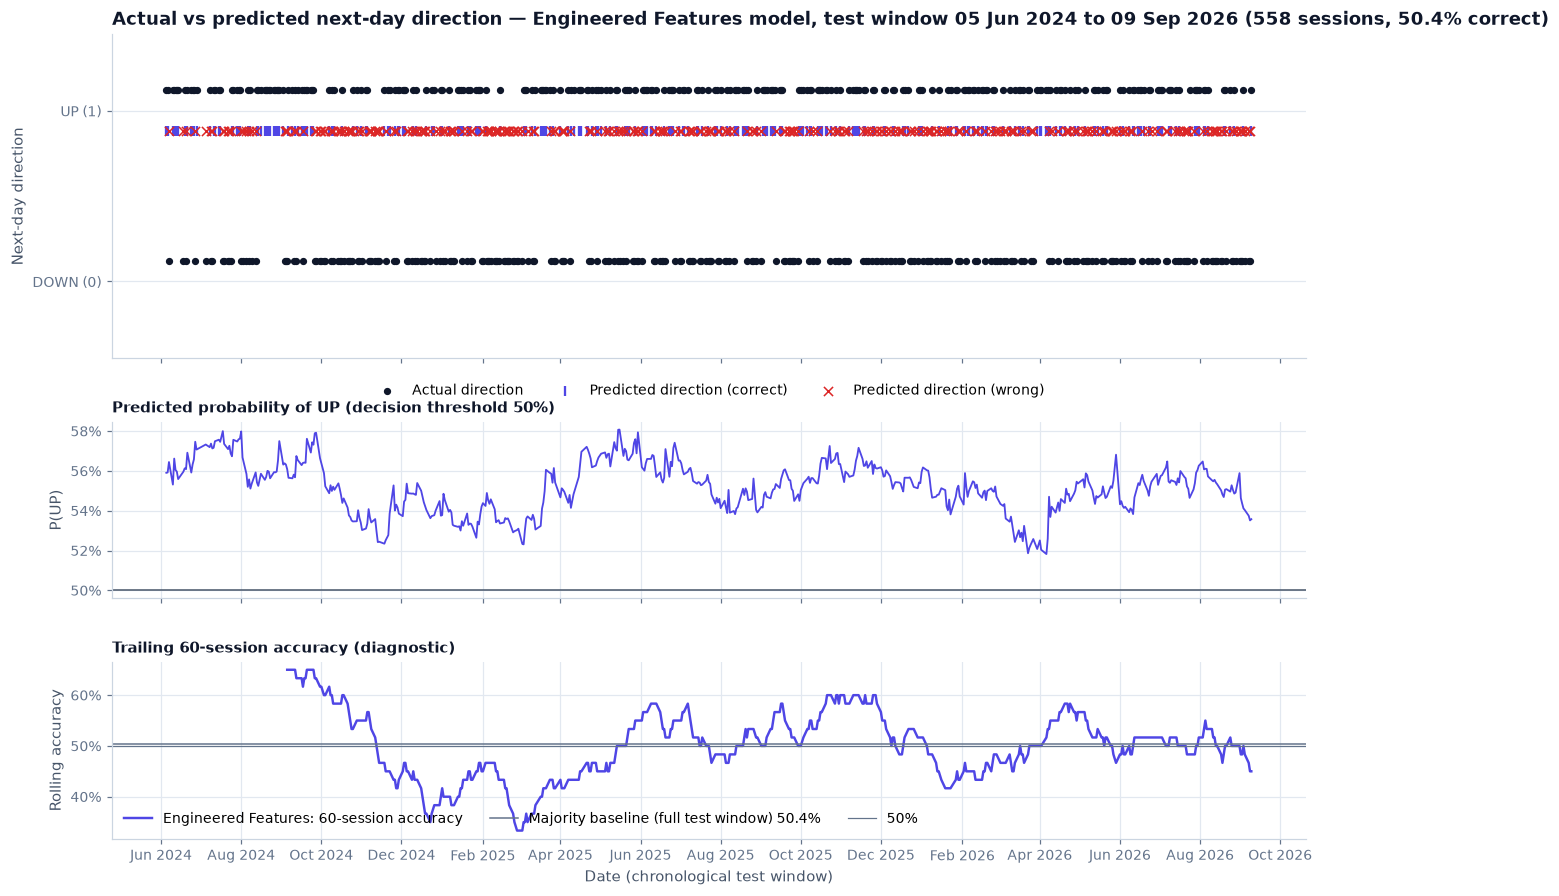

In [23]:
window = config.ROLLING_ACCURACY_WINDOW
rolling = pd.DataFrame({
    "Engineered": rolling_accuracy(y_test, pred["Engineered Features"], window),
    "Raw": rolling_accuracy(y_test, pred["Raw OHLCV"], window),
    "Persistence": rolling_accuracy(y_test, persistence_test, window),
    "Majority": rolling_accuracy(y_test, majority_test, window),
})

fig = plots.plot_actual_vs_predicted(test_predictions, "Engineered_Pred", "Engineered_Prob_Up",
                                     "Engineered Features", rolling["Engineered"], window,
                                     metrics["Majority Class"]["accuracy"])
plots.save_figure(fig, RESULTS / "actual_vs_predicted_direction.png")
plt.show()
plot_check = leakage.check_plot_data(test_predictions["Engineered_Pred"], eng_model.pipeline,
                                     split.test[ENGINEERED_FEATURES])

The same view for the raw OHLCV model, saved as `results/actual_vs_predicted_direction_raw.png`:

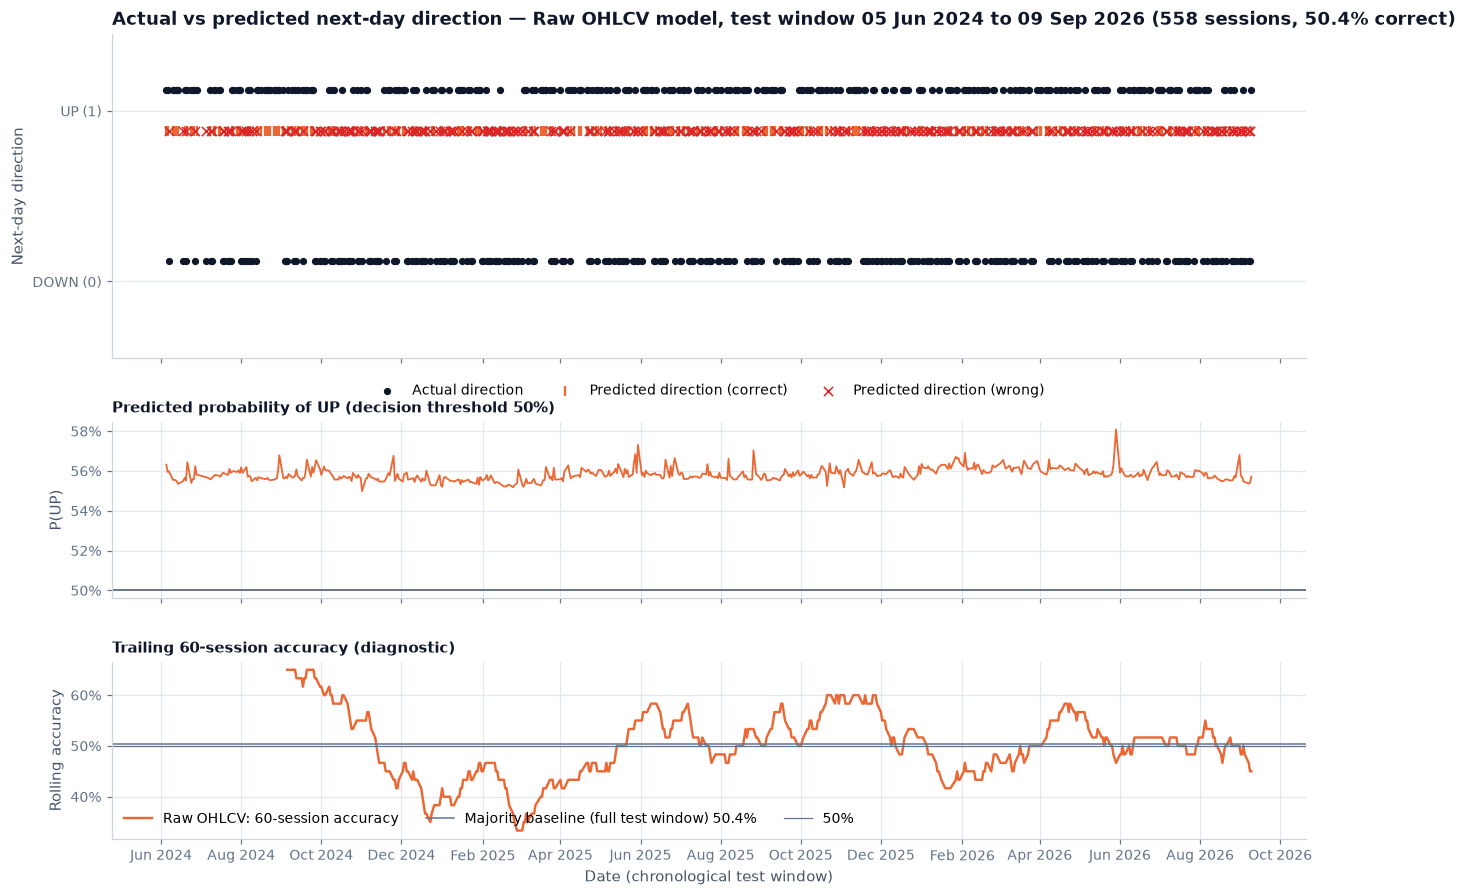

In [24]:
fig = plots.plot_actual_vs_predicted(test_predictions, "Raw_Pred", "Raw_Prob_Up", "Raw OHLCV",
                                     rolling["Raw"], window, metrics["Majority Class"]["accuracy"])
plots.save_figure(fig, RESULTS / "actual_vs_predicted_direction_raw.png")
plt.show()

## 24. Model Coefficients

Logistic-regression coefficients on standardised features. A positive value means that, with the other features held fixed, a higher value of the feature raises the model's predicted probability of UP. They describe associations learned by a regularised linear model on strongly correlated inputs (Close, SMA_20 and EMA_20 move almost together), not causal effects.

,Raw OHLCV,Engineered Features
Open,+0.0069,+0.0038
High,+0.0070,+0.0039
Low,+0.0070,+0.0037
Close,+0.0073,+0.0041
Volume,+0.0221,+0.0225
SMA_20,-,+0.0034
EMA_20,-,+0.0033
RSI_14,-,+0.0185
MACD,-,+0.0110
MACD_Signal,-,+0.0138


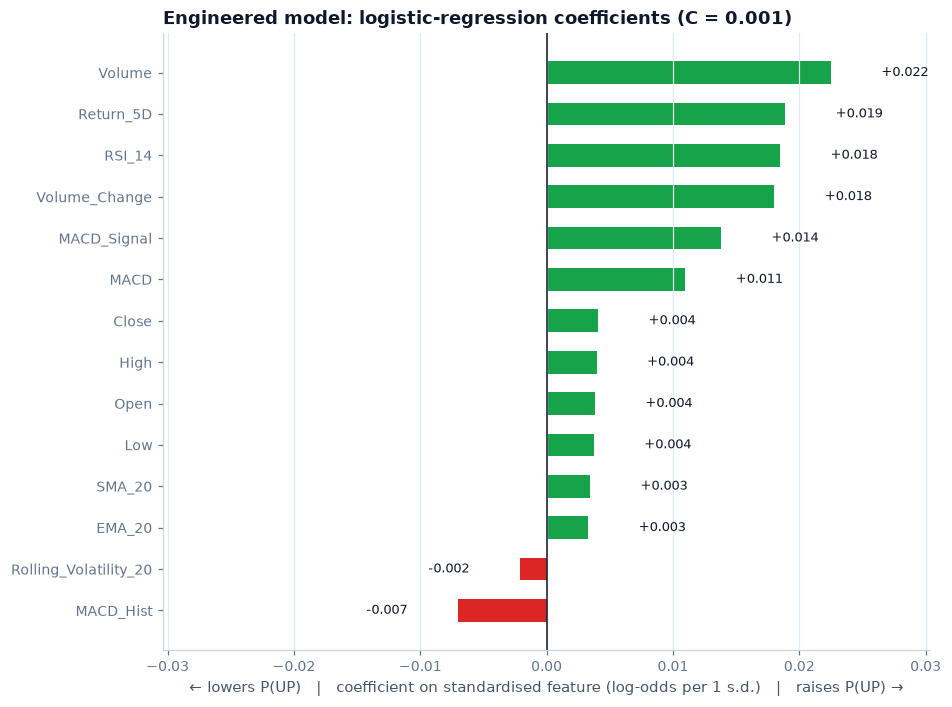

In [25]:
coefficients = pd.DataFrame({name: m.coefficients() for name, m in tuned.items()}).reindex(ENGINEERED_FEATURES)
coefficients.loc["(intercept)"] = [m.intercept() for m in tuned.values()]
coefficients.to_csv(RESULTS / "model_coefficients.csv", float_format="%.6f")
display(coefficients.style.format("{:+.4f}", na_rep="-"))

fig = plots.plot_coefficients(eng_model.coefficients(),
                              f"Engineered model: logistic-regression coefficients (C = {eng_model.best_C:g})")
plots.save_figure(fig, RESULTS / "engineered_model_coefficients.png")
plt.show()

## 25. Final Leakage Audit

Every programmatic check from the project's validation checklist, collected in one table and exported to `results/leakage_checks.csv`. CHECK 14 re-reads the exported files from disk. The notebook stops with an error if any check fails.

In [26]:
exports_check = leakage.check_exported_results(
    RESULTS, metrics,
    {"Persistence": "Persistence", "Majority Class": "Majority",
     "Raw OHLCV": "Raw_Pred", "Engineered Features": "Engineered_Pred"},
)
all_checks = (data_checks + split_checks + baseline_checks + [cv_check] + model_checks
              + [leakage.check_model_inputs(split.train[ENGINEERED_FEATURES], split.test[ENGINEERED_FEATURES]),
                 same_window_check, exports_check, plot_check])
all_checks.sort(key=lambda check: int(check.ref.split()[-1]))

leakage.to_frame(all_checks).to_csv(RESULTS / "leakage_checks.csv", index=False)
show_checks(all_checks)
assert all(check.passed for check in all_checks), "leakage audit failed: results must not be used"
print(f"{sum(check.passed for check in all_checks)}/{len(all_checks)} leakage and validity checks passed")

ref,stage,name,status,detail
CHECK 1,Data,Dates sorted chronologically,PASS,2879 sessions from 2015-01-02 to 2026-09-10 are strictly increasing.
CHECK 2,Data,No duplicate dates,PASS,0 duplicated dates after cleaning.
CHECK 3,Target,Target equals next-day movement,PASS,Independent recomputation of 1[Close(t+1) > Close(t)] matches all 2878 labels; the final row's label is undefined (NaN).
CHECK 4,Target,Final unlabeled row excluded,PASS,2026-09-10 has no next close and is absent from the modeling data.
CHECK 5,Features,No look-ahead constructs in feature code,PASS,"Syntax-tree scan of features.py and baselines.py found no negative shift, centred window, backward fill or interpolation; 1 shift(periods) call(s) take a variable lag, which trailing_return() restricts to positive values and the truncation test verifies numerically."
CHECK 5,Features,Features unchanged when the future is removed,PASS,All 14 features recomputed on 40 truncated histories; largest absolute difference = 0.0e+00.
CHECK 6,Features,Target and next-day columns excluded from features,PASS,"Neither feature set contains Target, Next_Close, Next_Date or the Persistence helper columns."
CHECK 6,Features,No NaN or infinite values in model inputs,PASS,2233 train and 558 test rows x 14 features are all finite.
CHECK 7,Split,Train period ends before test period,PASS,max(train date) = 2024-06-03 < min(test date) = 2024-06-05.
CHECK 7,Split,Every training label resolved before the test window,PASS,Latest Close(t+1) used by a training label is from 2024-06-04; 1 embargo row(s) purged.


19/19 leakage and validity checks passed


## 26. Interpretation of Results

Each answer below is generated from the computed metrics, so the text cannot drift from the numbers.

In [27]:
answers = answer_research_questions(metrics, significance, balance)
display(pd.DataFrame(answers).set_index("question")
        .style.set_properties(**{"text-align": "left", "white-space": "normal"}))

,verdict,answer
question,,
Did the raw model beat Persistence?,No,Raw OHLCV accuracy 50.36% vs Persistence 54.12% (-3.76 pp).
Did the raw model beat Majority Class?,Tie,Raw OHLCV accuracy 50.36% vs Majority 50.36% (+0.00 pp). The raw model predicted UP on 100.0% of test days.
Did the engineered model beat the raw model?,Tie,Engineered 50.36% vs Raw 50.36% (+0.00 pp); exact McNemar p = 1.000 on 0 discordant days.
Did the engineered model beat both naive baselines?,No,vs Persistence -3.76 pp; vs Majority +0.00 pp.
By how much?,-3.76 pp,Against the stronger baseline (Persistence) the engineered model differs by -3.76 pp. Its 95% Wilson interval for accuracy is 46.2% to 54.5%.
Is the improvement practically meaningful or only marginal?,Marginal / not established,The difference to Persistence is -3.76 pp with exact McNemar p = 0.229. The project's pre-set bar for 'meaningful' is at least 2 pp AND p < 0.05; this bar is not met.
How does class imbalance affect interpretation?,Balanced,"UP days are 53.9% of training labels and 50.4% of test labels, so always predicting 'UP' already scores 50.36%. Accuracy must be read relative to that floor; balanced accuracy (Engineered 50.00%, Raw 50.00%) removes the advantage of favouring the majority class."
Are there signs that the model is close to naive performance?,Yes,"The engineered model is +0.00 pp from the Majority baseline, predicts UP on 100.0% of days and has ROC-AUC 0.506 (0.5 = no ranking skill)."


In [28]:
eng, raw_m = metrics["Engineered Features"], metrics["Raw OHLCV"]
pers, maj = metrics["Persistence"], metrics["Majority Class"]
display(Markdown("\n".join([
    "**Discussion.**",
    "",
    f"* **Behaviour on the test window.** The raw model predicted UP on {raw_m['predicted_up_rate']:.1%} of test days "
    f"and the engineered model on {eng['predicted_up_rate']:.1%}; {test_row['UP %']:.1%} of test days were actually UP.",
    f"* **Ranking skill.** ROC-AUC is {raw_m['roc_auc']:.3f} for the raw model and {eng['roc_auc']:.3f} for the "
    "engineered model. A value of 0.5 means the predicted probabilities do not rank UP days above DOWN days.",
    f"* **Balanced accuracy** (mean recall of both classes) is {pers['balanced_accuracy']:.2%} for Persistence, "
    f"{maj['balanced_accuracy']:.2%} for Majority, {raw_m['balanced_accuracy']:.2%} for Raw and "
    f"{eng['balanced_accuracy']:.2%} for Engineered. Unlike accuracy, it gives no credit for simply favouring the "
    "more frequent class.",
    f"* **Uncertainty.** With {eng['n']} test days, a 95% interval around an accuracy is about "
    f"±{(eng['accuracy_ci_high'] - eng['accuracy_ci_low']) / 2:.1%} wide, so differences of one or two percentage "
    "points between approaches are within sampling noise unless the paired McNemar test says otherwise.",
])))

**Discussion.**

* **Behaviour on the test window.** The raw model predicted UP on 100.0% of test days and the engineered model on 100.0%; 50.4% of test days were actually UP.
* **Ranking skill.** ROC-AUC is 0.508 for the raw model and 0.506 for the engineered model. A value of 0.5 means the predicted probabilities do not rank UP days above DOWN days.
* **Balanced accuracy** (mean recall of both classes) is 54.12% for Persistence, 50.00% for Majority, 50.00% for Raw and 50.00% for Engineered. Unlike accuracy, it gives no credit for simply favouring the more frequent class.
* **Uncertainty.** With 558 test days, a 95% interval around an accuracy is about ±4.1% wide, so differences of one or two percentage points between approaches are within sampling noise unless the paired McNemar test says otherwise.

## 27. Limitations

In [29]:
display(Markdown("\n".join(f"- {item}" for item in LIMITATIONS)))

- Financial markets are noisy and non-stationary; next-day direction is close to a coin flip and small accuracy differences can arise by chance.
- Relationships learned from 2015-2024 can weaken or reverse in a new regime (policy shocks, pandemics, changes in market microstructure).
- Technical indicators summarise past prices; they carry no guarantee of predictive power.
- Raw price levels (Open, High, Low, Close, SMA_20, EMA_20) and MACD in index points are non-stationary: the test period trades at levels partly outside the training range, which a linear model extrapolates poorly.
- One index over one period does not establish that the approach generalises to other assets or markets.
- Classification accuracy is not trading profitability: transaction costs, slippage, taxes and position sizing are not modelled, and no trading strategy was evaluated.
- The test window is a single chronological hold-out; results on other windows could differ.
- Yahoo Finance data can be revised, and a few sessions lack reported volume; the committed snapshot and its checksum pin the data used here.

## 28. Final Conclusion

In [30]:
acc = {name: m["accuracy"] for name, m in metrics.items()}
diff_pp = 100 * (acc["Engineered Features"] - acc["Raw OHLCV"])
p_raw = significance["Engineered Features vs Raw OHLCV"]["p_value"]
if diff_pp > 0:
    indicators_answer = (f"Accuracy rose by {diff_pp:.2f} percentage points over the raw model (exact McNemar "
                         f"p = {p_raw:.3f})" + (", a statistically detectable difference." if p_raw < config.ALPHA
                                                else ", a difference that is not statistically distinguishable from chance on this test window."))
elif diff_pp == 0:
    indicators_answer = "No. Both models reached exactly the same accuracy on the test window."
else:
    indicators_answer = (f"No. The engineered model was {abs(diff_pp):.2f} percentage points less accurate than the "
                         f"raw model (exact McNemar p = {p_raw:.3f}).")

best_model = max(["Raw OHLCV", "Engineered Features"], key=acc.get)
best_baseline = max(["Persistence", "Majority Class"], key=acc.get)
gap_pp = 100 * (acc[best_model] - acc[best_baseline])
meaningful = next(a for a in answers if a["question"].startswith("Is the improvement"))
if meaningful["verdict"] == "Meaningful":
    predictability = (f"The better model ({best_model}, {acc[best_model]:.2%}) beats the best naive rule "
                      f"({best_baseline}, {acc[best_baseline]:.2%}) by {gap_pp:.2f} pp, a detectable but modest edge "
                      "that says nothing about profitability after costs.")
else:
    predictability = (f"The better model ({best_model}, {acc[best_model]:.2%}) is {gap_pp:+.2f} pp from the best naive "
                      f"rule ({best_baseline}, {acc[best_baseline]:.2%}). On this evidence, next-day direction of the "
                      "NIFTY 50 is not meaningfully predictable from daily OHLCV data and standard technical indicators "
                      "with a linear classifier. That is consistent with a noisy daily return series in which past "
                      "prices carry little exploitable information.")

passed = sum(check.passed for check in all_checks)
display(Markdown("\n".join([
    f"1. **Dataset.** NIFTY 50 (`^NSEI`) daily OHLCV from Yahoo Finance, {clean.index.min():%d %b %Y} to "
    f"{clean.index.max():%d %b %Y}: {len(clean):,} sessions, of which {len(frame):,} are usable labelled rows.",
    "2. **Target.** Next-session direction: 1 (UP) if Close(t+1) > Close(t), otherwise 0 (DOWN).",
    "3. **Leakage prevention.** The forward shift is used only to build the label; indicators are causal pandas "
    f"computations (truncation test: maximum difference {truncation_detail['max_abs_difference'].max():.1e}); the split "
    "is chronological with a one-session embargo; the scaler and the hyperparameter search only see training rows; "
    f"{passed}/{len(all_checks)} audit checks passed.",
    f"4. **Naive baselines.** Persistence {acc['Persistence']:.2%}; Majority Class {acc['Majority Class']:.2%} "
    f"(always {'UP' if majority else 'DOWN'}, taken from the training labels).",
    f"5. **Raw OHLCV model.** Accuracy {acc['Raw OHLCV']:.2%} (balanced accuracy {raw_m['balanced_accuracy']:.2%}, "
    f"ROC-AUC {raw_m['roc_auc']:.3f}, C = {raw_model.best_C:g}).",
    f"6. **Engineered model.** Accuracy {acc['Engineered Features']:.2%} (balanced accuracy "
    f"{eng['balanced_accuracy']:.2%}, ROC-AUC {eng['roc_auc']:.3f}, C = {eng_model.best_C:g}).",
    f"7. **Did technical indicators improve performance?** {indicators_answer}",
    f"8. **Was the improvement meaningful?** {meaningful['verdict']}. {meaningful['answer']}",
    f"9. **What this says about predictability.** {predictability}",
    "10. **Major limitations.** Non-stationarity and regime change, a single hold-out window on a single index, "
    "non-stationary price-level features, and no modelling of costs or trading: accuracy is not profitability.",
])))

1. **Dataset.** NIFTY 50 (`^NSEI`) daily OHLCV from Yahoo Finance, 02 Jan 2015 to 10 Sep 2026: 2,879 sessions, of which 2,792 are usable labelled rows.
2. **Target.** Next-session direction: 1 (UP) if Close(t+1) > Close(t), otherwise 0 (DOWN).
3. **Leakage prevention.** The forward shift is used only to build the label; indicators are causal pandas computations (truncation test: maximum difference 0.0e+00); the split is chronological with a one-session embargo; the scaler and the hyperparameter search only see training rows; 19/19 audit checks passed.
4. **Naive baselines.** Persistence 54.12%; Majority Class 50.36% (always UP, taken from the training labels).
5. **Raw OHLCV model.** Accuracy 50.36% (balanced accuracy 50.00%, ROC-AUC 0.508, C = 0.001).
6. **Engineered model.** Accuracy 50.36% (balanced accuracy 50.00%, ROC-AUC 0.506, C = 0.001).
7. **Did technical indicators improve performance?** No. Both models reached exactly the same accuracy on the test window.
8. **Was the improvement meaningful?** Marginal / not established. The difference to Persistence is -3.76 pp with exact McNemar p = 0.229. The project's pre-set bar for 'meaningful' is at least 2 pp AND p < 0.05; this bar is not met.
9. **What this says about predictability.** The better model (Raw OHLCV, 50.36%) is -3.76 pp from the best naive rule (Persistence, 54.12%). On this evidence, next-day direction of the NIFTY 50 is not meaningfully predictable from daily OHLCV data and standard technical indicators with a linear classifier. That is consistent with a noisy daily return series in which past prices carry little exploitable information.
10. **Major limitations.** Non-stationarity and regime change, a single hold-out window on a single index, non-stationary price-level features, and no modelling of costs or trading: accuracy is not profitability.

## Appendix: Export for the Web Dashboard

The dashboard in the repository root renders `results/dashboard.json`; it does not recompute anything. The engineered model's output for the session after the last date in the data is included for completeness. It is a research output, not a trading signal or investment advice.

In [31]:
latest_features = labelled[ENGINEERED_FEATURES].iloc[[-1]]
next_session = None
if bool(latest_features.notna().all(axis=None)):
    p_up = float(eng_model.pipeline.predict_proba(latest_features)[0, 1])
    next_session = {
        "basedOnDate": f"{latest_features.index[0]:%Y-%m-%d}",
        "model": "Engineered Features",
        "probabilityUp": p_up,
        "prediction": int(p_up >= 0.5),
        "note": ("Output of the evaluated engineered model for the first session after the data ends. "
                 "Research output only: not a trading signal or investment advice."),
    }
    display(pd.Series(next_session, name="value").to_frame())

artifacts = [
    {"file": "four_way_comparison.csv", "label": "Four-way comparison", "kind": "csv"},
    {"file": "class_balance.csv", "label": "Class balance report", "kind": "csv"},
    {"file": "test_predictions.csv", "label": "Test-window predictions", "kind": "csv"},
    {"file": "classification_reports.csv", "label": "Classification reports", "kind": "csv"},
    {"file": "confusion_matrices.csv", "label": "Confusion matrices", "kind": "csv"},
    {"file": "cv_results.csv", "label": "Cross-validation results", "kind": "csv"},
    {"file": "model_coefficients.csv", "label": "Model coefficients", "kind": "csv"},
    {"file": "leakage_checks.csv", "label": "Leakage audit", "kind": "csv"},
    {"file": "actual_vs_predicted_direction.png", "label": "Actual vs predicted (engineered)", "kind": "png"},
    {"file": "actual_vs_predicted_direction_raw.png", "label": "Actual vs predicted (raw)", "kind": "png"},
    {"file": "four_way_comparison.png", "label": "Four-way comparison chart", "kind": "png"},
    {"file": "confusion_matrices.png", "label": "Confusion matrices chart", "kind": "png"},
    {"file": "class_balance.png", "label": "Class balance chart", "kind": "png"},
    {"file": "train_test_split.png", "label": "Train / test split chart", "kind": "png"},
    {"file": "cv_accuracy_by_C.png", "label": "Cross-validation chart", "kind": "png"},
    {"file": "engineered_model_coefficients.png", "label": "Coefficient chart", "kind": "png"},
    {"file": "dashboard.json", "label": "Dashboard data (JSON)", "kind": "json"},
]

payload = build_payload(
    metadata=metadata, cleaning=cleaning_report, clean=clean, labelled=labelled, frame=frame,
    exclusions=exclusions, unchanged_closes=unchanged_closes, split=split, balance=balance,
    majority_class=majority, majority_summary=majority_summary, tuned=tuned, folds=folds,
    cv_description=cv_description, metrics=metrics, significance=significance, reports=reports,
    predictions=test_predictions, rolling=rolling, checks=all_checks, truncation=truncation_detail,
    truncation_points=config.TRUNCATION_TEST_POINTS, answers=answers, next_session=next_session,
    environment=environment, artifacts=artifacts,
)
path = write_payload(payload)
missing_files = [a["file"] for a in artifacts if not (RESULTS / a["file"]).exists()]
assert not missing_files, f"missing artifacts: {missing_files}"
print(f"Wrote results/{path.name} ({path.stat().st_size / 1024:.0f} KB); all {len(artifacts)} artifacts present.")

,value
basedOnDate,2026-09-10
model,Engineered Features
probabilityUp,0.533691
prediction,1
note,Output of the evaluated engineered model for t...


Wrote results/dashboard.json (286 KB); all 17 artifacts present.
